In [2]:
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt 
from itertools import combinations
from collections import Counter 

In [3]:
df=pd.read_csv(r"C:\Users\altam\Documents\cleaned_train.csv")
print("Data Preview")
print(df.head())
print("\n Columns in CSV :", df.columns.tolist())

conn=sqlite3.connect("sales_data.db")
df.to_sql('sales', conn, index=False, if_exists='replace')
print("\nCreated SQLite database 'sales_data.db' with table 'sales'")

Data Preview
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
1       2  CA-2017-152156  08-11-2017  11-11-2017    Second Class    CG-12520   
2       3  CA-2017-138688  12-06-2017  16-06-2017    Second Class    DV-13045   
3       4  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   
4       5  US-2016-108966  11-10-2016  18-10-2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product I


Using columns:
  Product: Product Name
  Revenue: Sales

Sales Summary:
                                             product    revenue
0              Canon imageCLASS 2200 Advanced Copier  61599.824
1  Fellowes PB500 Electric Punch Plastic Comb Bin...  27453.384
2  Cisco TelePresence System EX90 Videoconferenci...  22638.480
3       HON 5400 Series Task Chairs for Big and Tall  21870.576
4         GBC DocuBind TL300 Electric Binding System  19823.479
5   GBC Ibimaster 500 Manual ProClick Binding System  19024.500
6               Hewlett Packard LaserJet 3310 Copier  18839.686
7  HP Designjet T520 Inkjet Large Format Printer ...  18374.895
8          GBC DocuBind P400 Electric Binding System  17965.068
9        High Speed Automatic Electric Letter Opener  17030.312


<Figure size 1400x800 with 0 Axes>

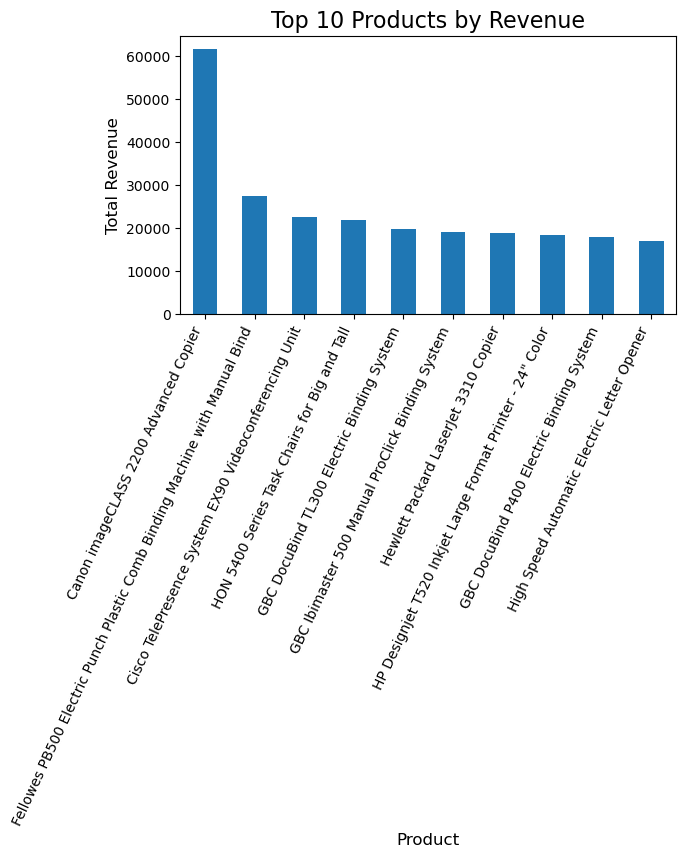


Database connection closed.


In [5]:

# Step 3: Set analysis columns manually
product_col = 'Product Name'     # Or use 'Sub-Category' or 'Category' for grouping
revenue_col = 'Sales'

print(f"\nUsing columns:")
print(f"  Product: {product_col}")
print(f"  Revenue: {revenue_col}")

# Step 4: SQL query to get total revenue per product
query = f"""
SELECT "{product_col}" AS product, 
       SUM("{revenue_col}") AS revenue 
FROM sales 
GROUP BY "{product_col}" 
ORDER BY revenue DESC
"""

sales_summary = pd.read_sql_query(query, conn)
print("\nSales Summary:")
print(sales_summary.head(10))  # Display top 10 products

# Step 5: Plot - Revenue by Product (Top 10)
top_n = 10
top_products = sales_summary.head(top_n)

plt.figure(figsize=(14, 8))  # Increased height
ax = top_products.plot(kind='bar', x='product', y='revenue', legend=False)

plt.title(f'Top {top_n} Products by Revenue', fontsize=16)
plt.xlabel('Product', fontsize=12)
plt.ylabel('Total Revenue', fontsize=12)
plt.xticks(rotation=65, ha='right', fontsize=10)

plt.subplots_adjust(bottom=0.3)  # Make space for long product names
plt.savefig("top_products_revenue.png", bbox_inches='tight')
plt.show()


# Step 6: Close DB connection
conn.close()
print("\nDatabase connection closed.")


In [6]:
sales_summary = df.groupby('Customer Name').agg(
    revenue=('Sales', 'sum'),
    total_qty=('Product Name', 'count')  # Or other logic for quantity if available
).reset_index()


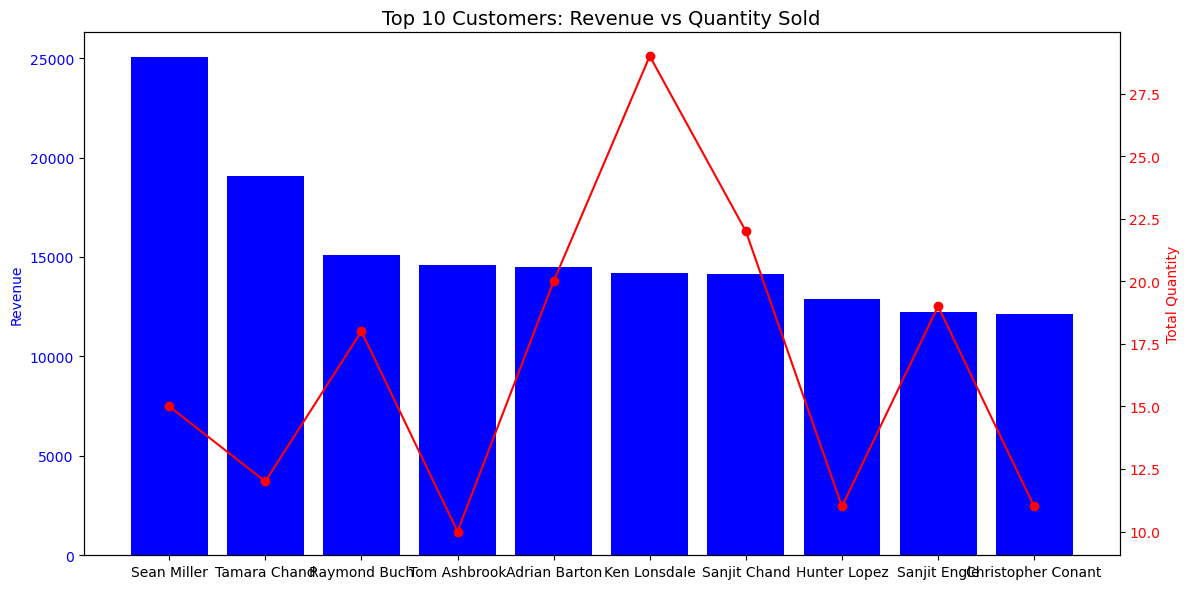

In [7]:
# Limit to top 10 customers by revenue
top_customers = sales_summary.sort_values(by='revenue', ascending=False).head(10)

fig, ax1 = plt.subplots(figsize=(12, 6))

# Create the second y-axis
ax2 = ax1.twinx()

# Bar plot for revenue
ax1.bar(top_customers['Customer Name'], top_customers['revenue'], color='blue', label='Revenue')
ax1.set_ylabel('Revenue', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Line plot for total quantity
ax2.plot(top_customers['Customer Name'], top_customers['total_qty'], color='red', marker='o', label='Total Quantity')
ax2.set_ylabel('Total Quantity', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# X-axis labels and layout
plt.xticks(rotation=65, ha='right', fontsize=9)
plt.title('Top 10 Customers: Revenue vs Quantity Sold', fontsize=14)
plt.tight_layout()
plt.savefig("top_customers_revenue_quantity_dual_axis.png", bbox_inches='tight')
plt.show()


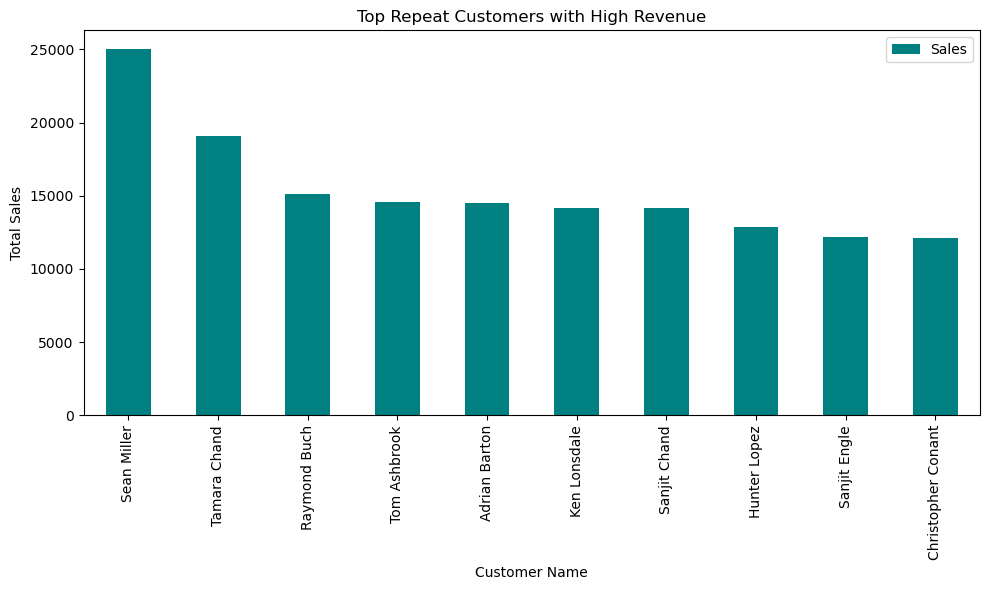

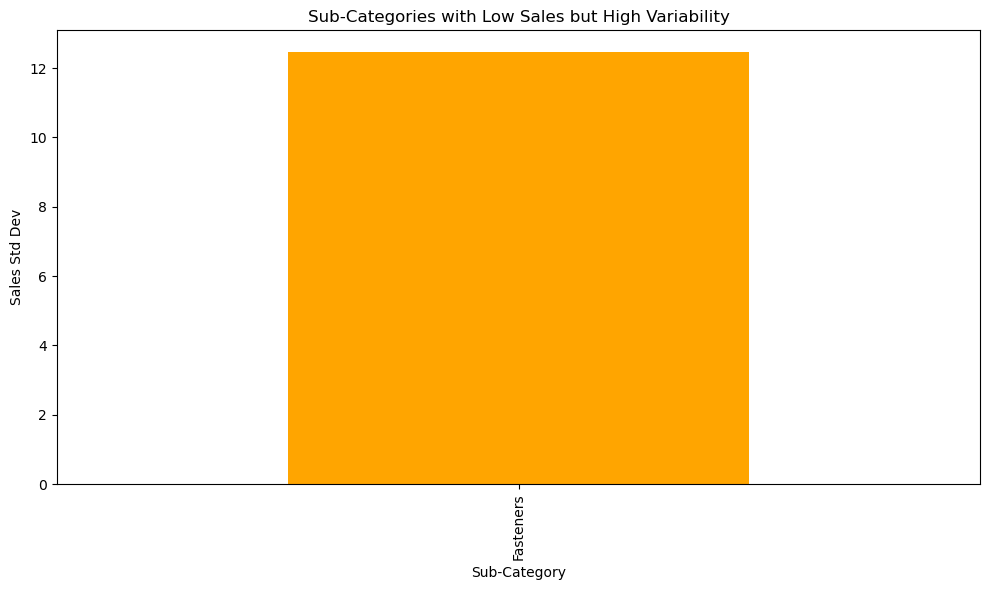

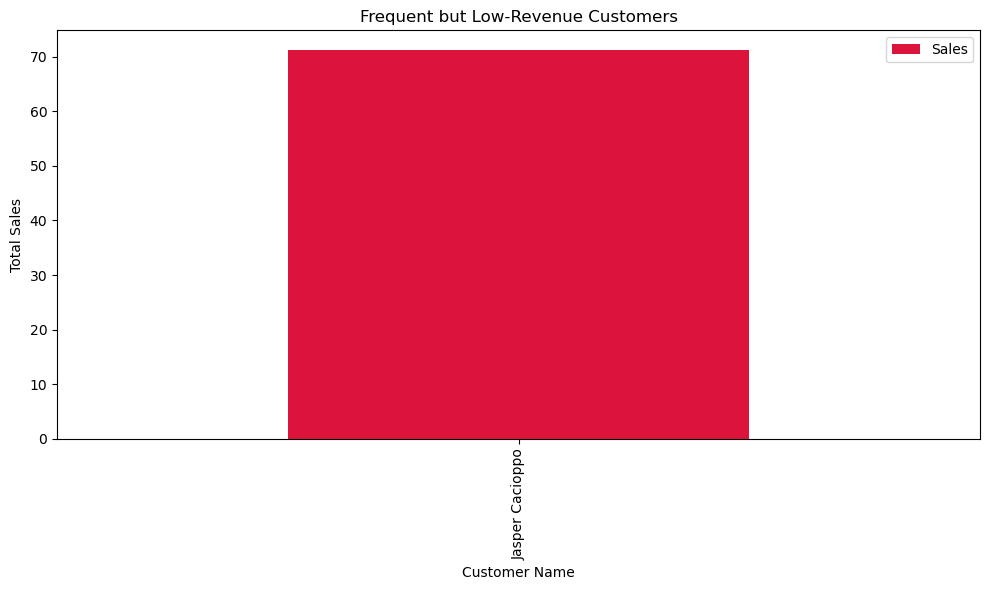

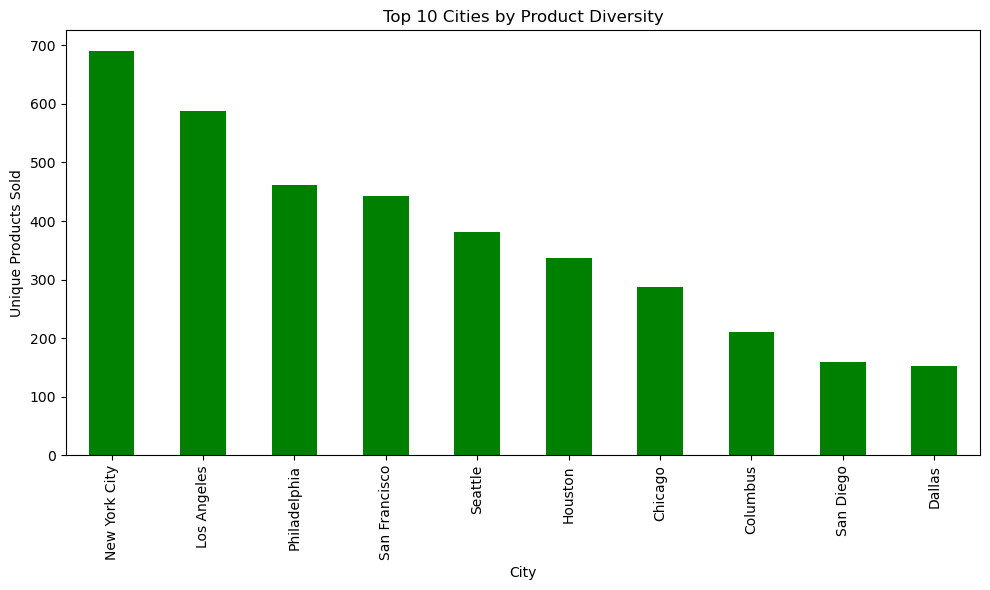

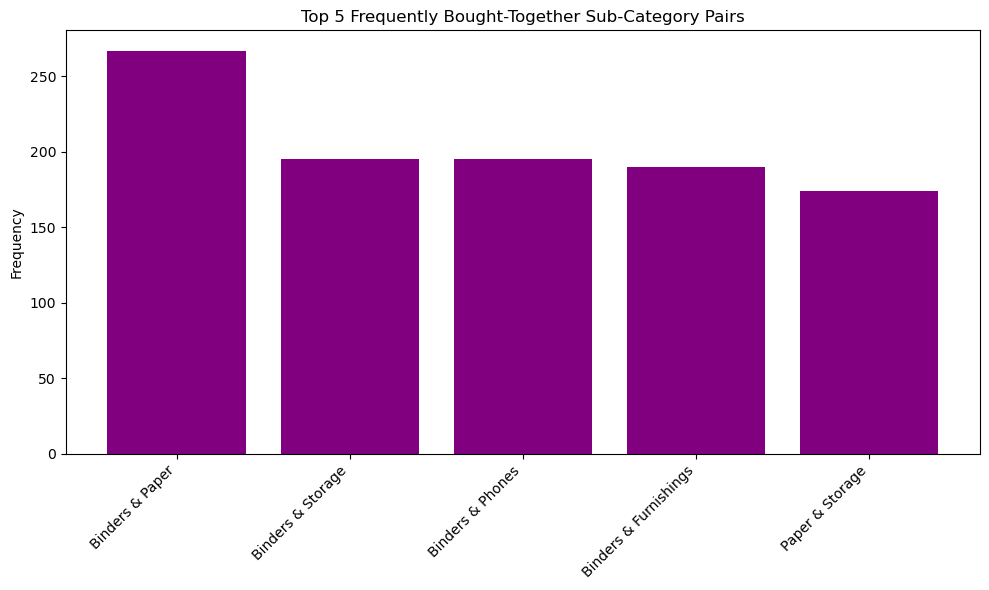

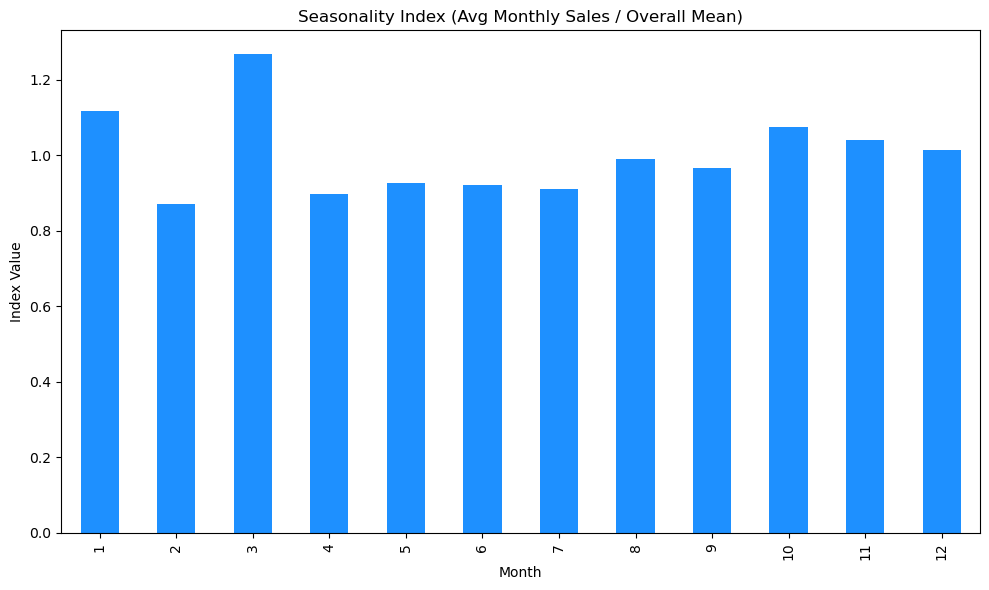

In [8]:

# Convert date column to datetime
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)

# Set up plot size
plt.rcParams["figure.figsize"] = (10, 6)

# --- Insight 1: Repeat Customers with High Revenue ---
repeat_customers = df.groupby('Customer Name').agg({
    'Order ID': pd.Series.nunique,
    'Sales': 'sum'
}).reset_index()

repeat_customers = repeat_customers[repeat_customers['Order ID'] > 1]
high_value_repeat = repeat_customers.sort_values(by='Sales', ascending=False).head(10)

fig1, ax1 = plt.subplots()
high_value_repeat.plot(kind='bar', x='Customer Name', y='Sales', ax=ax1, color='teal')
ax1.set_title("Top Repeat Customers with High Revenue")
ax1.set_ylabel("Total Sales")
plt.tight_layout()
plt.show()

# --- Insight 2: Sub-Categories with Low Sales but High Variability ---
sales_std = df.groupby('Sub-Category')['Sales'].std()
low_total_sales = df.groupby('Sub-Category')['Sales'].sum()
low_sales_high_variance = sales_std[(low_total_sales < 5000)].sort_values(ascending=False)

fig2, ax2 = plt.subplots()
low_sales_high_variance.plot(kind='bar', color='orange', ax=ax2)
ax2.set_title("Sub-Categories with Low Sales but High Variability")
ax2.set_ylabel("Sales Std Dev")
plt.tight_layout()
plt.show()

# --- Insight 3: Frequent but Low-Revenue Customers ---
customer_sales = df.groupby('Customer Name').agg({
    'Order ID': pd.Series.nunique,
    'Sales': 'sum'
}).reset_index()

low_value_frequent = customer_sales[
    (customer_sales['Order ID'] > 3) & (customer_sales['Sales'] < 100)
]

fig3, ax3 = plt.subplots()
low_value_frequent.sort_values(by='Sales', ascending=False).head(10).plot(
    kind='bar', x='Customer Name', y='Sales', ax=ax3, color='crimson'
)
ax3.set_title("Frequent but Low-Revenue Customers")
ax3.set_ylabel("Total Sales")
plt.tight_layout()
plt.show()

# --- Insight 4: City-wise Product Diversity ---
city_product_diversity = df.groupby('City')['Product ID'].nunique().sort_values(ascending=False).head(10)

fig4, ax4 = plt.subplots()
city_product_diversity.plot(kind='bar', color='green', ax=ax4)
ax4.set_title("Top 10 Cities by Product Diversity")
ax4.set_ylabel("Unique Products Sold")
plt.tight_layout()
plt.show()

# --- Insight 5: Sub-Category Pairs Bought Together ---
order_products = df.groupby('Order ID')['Sub-Category'].apply(lambda x: list(set(x)))
combo_counter = Counter()

for products in order_products:
    if len(products) > 1:
        for combo in combinations(products, 2):
            combo_counter[tuple(sorted(combo))] += 1

most_common_combos = combo_counter.most_common(5)
combo_labels = [f"{a} & {b}" for (a, b), _ in most_common_combos]
combo_counts = [count for _, count in most_common_combos]

fig5, ax5 = plt.subplots()
ax5.bar(range(len(combo_labels)), combo_counts, color='purple')
ax5.set_title("Top 5 Frequently Bought-Together Sub-Category Pairs")
ax5.set_ylabel("Frequency")
ax5.set_xticks(range(len(combo_labels)))
ax5.set_xticklabels(combo_labels, rotation=45, ha='right')
plt.tight_layout()
plt.show()

# --- Insight 6: Seasonality Index ---
df['Month'] = df['Order Date'].dt.month
monthly_avg = df.groupby('Month')['Sales'].mean()
seasonality_index = monthly_avg / monthly_avg.mean()

fig6, ax6 = plt.subplots()
seasonality_index.plot(kind='bar', color='dodgerblue', ax=ax6)
ax6.set_title("Seasonality Index (Avg Monthly Sales / Overall Mean)")
ax6.set_ylabel("Index Value")
plt.tight_layout()
plt.show()


In [9]:

conn.close()
print("\nDatabase connection closed.")



Database connection closed.
